# Injecting Simulated Satellites to Quantify Dwarf Search Sensitivity in DP0

In [1]:
import os
import sys
sys.path.append(os.path.expandvars('$HOME/software/simple_adl'))
sys.path.append(os.path.expandvars('$HOME/software/'))
import glob
import yaml
import time

import numpy as np
import pandas as pd
# from pandas import *
from scipy import stats
from scipy.optimize import curve_fit

import fitsio as fits

import matplotlib.pyplot as plt
import seaborn as sns

from astropy import units as u
from astropy.coordinates import SkyCoord

import simple_adl.survey
import simple_adl.isochrone
from simple_adl.coordinate_tools import distanceModulusToDistance, angsep
from simple_adl.search import write_output, search_by_distance, cut_isochrone_path
from simple_adl.plot_osf import plot_osf
from simple_adl.query_TAP import query, query_truth
from simple_adl.load_data import load_simdf, load_sim_data
from simple_adl.plot import plots

from lsst.rsp import get_tap_service
import dc2_satellite_census.code.utils as sc_utils
import dc2_satellite_census.code.selection_function as selection_function

from IPython.core.debugger import set_trace
import importlib

## Plotting

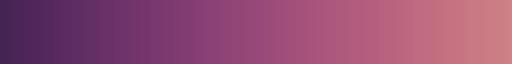

In [2]:
# cmap = sns.cubehelix_palette(start=1.0, rot=-1.0, light=0.8, dark=0.2, hue=1.0, reverse=True, as_cmap=True)
cmap = sns.cubehelix_palette(start=3.0, rot=0.5, light=0.6, dark=0.2, hue=1.0, reverse=True, as_cmap=True)
#cmap = sns.cubehelix_palette(start=0.0, rot=0.0, light=0.7, dark=0.3, hue=1.0, reverse=True, as_cmap=True)
#cmap = sns.cubehelix_palette(start=0.5, rot=0.0, light=0.7, dark=0.3, hue=1.0, reverse=True, as_cmap=True)

cmap

In [3]:
def save_regions(path: str):
    """ Save queried DC2 regions to disc
    Parameters
    ----------
    path: str
        Location to save regions
    """
    service = get_tap_service()
    assert service is not None
    assert service.baseurl == "https://data.lsst.cloud/api/tap"
    sim_dir = '/project/shared/data/satsim/lsst_dc2_v6'
    population_file = glob.glob(os.path.join(sim_dir, '*population*'))
    with open('config.yaml') as ymlfile:
        cfg = yaml.load(ymlfile, Loader=yaml.SafeLoader)
        survey = simple_adl.survey.Survey(cfg)
        
    i = 0
    radius = 2
    for file in population_file:
        sim_population = fits.read(file)
        sim_positions = np.unique(sim_population[['RA', 'DEC']])
        for position in sim_positions:
            outfile = path + f'/region_{i}'
            if os.path.exists(outfile):
                i += 1
            else:
                print(f'Querying {position[0], position[1]}')
                real_data = query(service, position[0], position[1], radius)  # pd.DataFrame
                real_data.insert(loc=0, column='center_ra', value=position[0])
                real_data.insert(loc=1, column='center_dec', value=position[1])
                print(f'Saving region_{i}')
                real_data.to_csv(outfile)
                i += 1
            
    return

In [4]:
from lsst.rsp import get_tap_service

service = get_tap_service()
assert service is not None
assert service.baseurl == "https://data.lsst.cloud/api/tap"

/tmp/ipykernel_9679/4062763552.py:3: DeprecationWarning: get_tap_service() is deprecated, use get_tap_service("tap")
  service = get_tap_service()


## Main loop over simulated satellites per position

In [22]:
# Set location of the simulated satellite files
sim_dir = '/project/shared/data/satsim/lsst_dc2_v6'
population_file = glob.glob(os.path.join(sim_dir, '*population*'))

0027301-0027400
Querying region (55.223614, -38.647755)
Satellites at  (55.223614, -38.647755) :
 [27381 27383 27384 27386 27387 27389 27390]


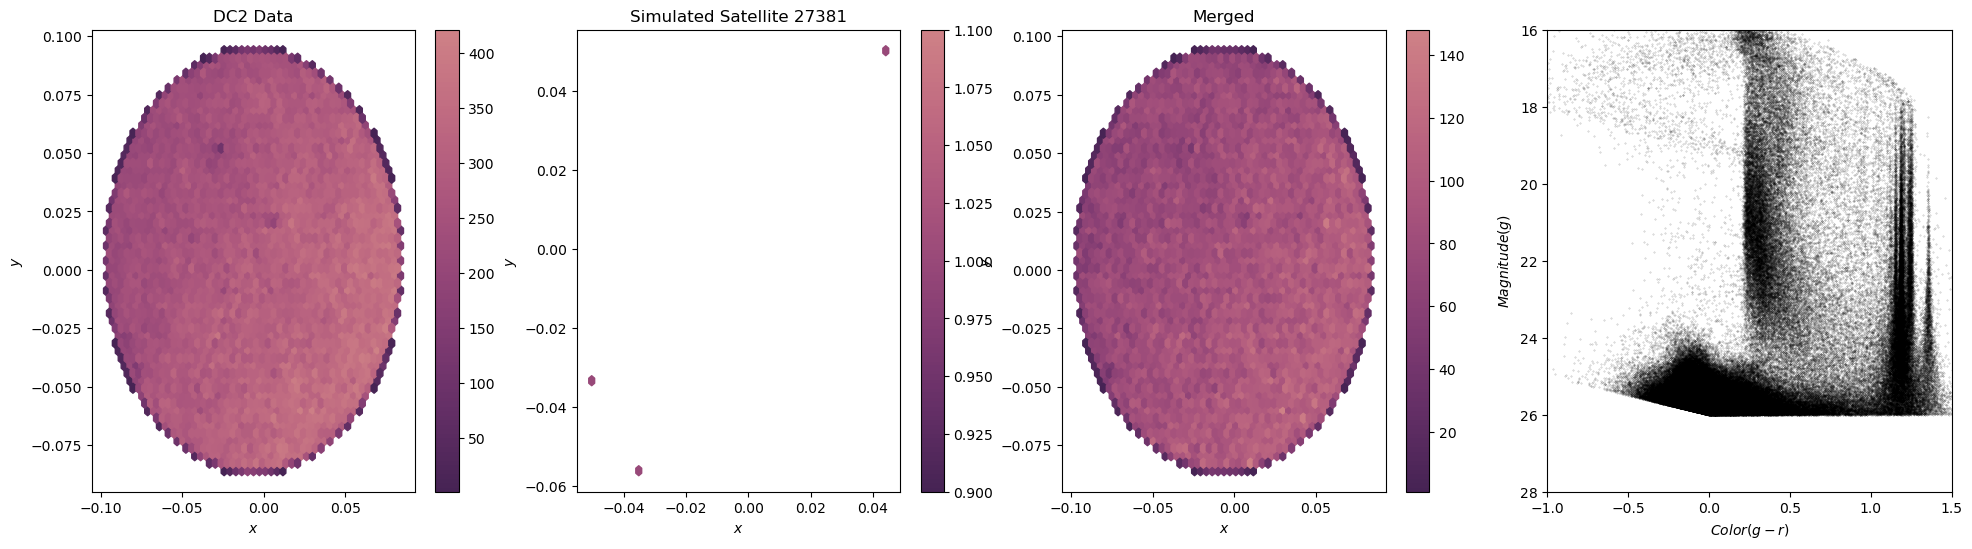

Searching for MC_SOURCE_ID  27381


/home/kb/.conda/envs/simple/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kb/.conda/envs/simple/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Characteristic density = 1300.0 deg^-2
Fitting aperture to hotspot...
Characteristic density local = 1350.8 deg^-2 = 0.375 arcmin^-2
Candidate: x_peak:       -1.215, y_peak:       -0.105, r_peak:        0.030, sig:        3.572, ra_peak:       53.666, dec_peak:      -38.742
Fitting aperture to hotspot...
Characteristic density local = 1386.6 deg^-2 = 0.385 arcmin^-2
Candidate: x_peak:       -0.735, y_peak:       -0.065, r_peak:        0.020, sig:        3.756, ra_peak:       54.282, dec_peak:      -38.709
Fitting aperture to hotspot...
Characteristic density local = 1382.7 deg^-2 = 0.384 arcmin^-2
Candidate: x_peak:       -0.485, y_peak:        0.235, r_peak:        0.050, sig:        3.592, ra_peak:       54.605, dec_peak:      -38.411
Fitting aperture to hotspot...
Characteristic density local = 1231.5 deg^-2 = 0.342 arcmin^-2
Candidate: x_peak:       -0.505, y_peak:        1.095, r_peak:        0.030, sig:        4.465, ra_peak:       54.587, dec_peak:      -37.551
Fitting aperture 

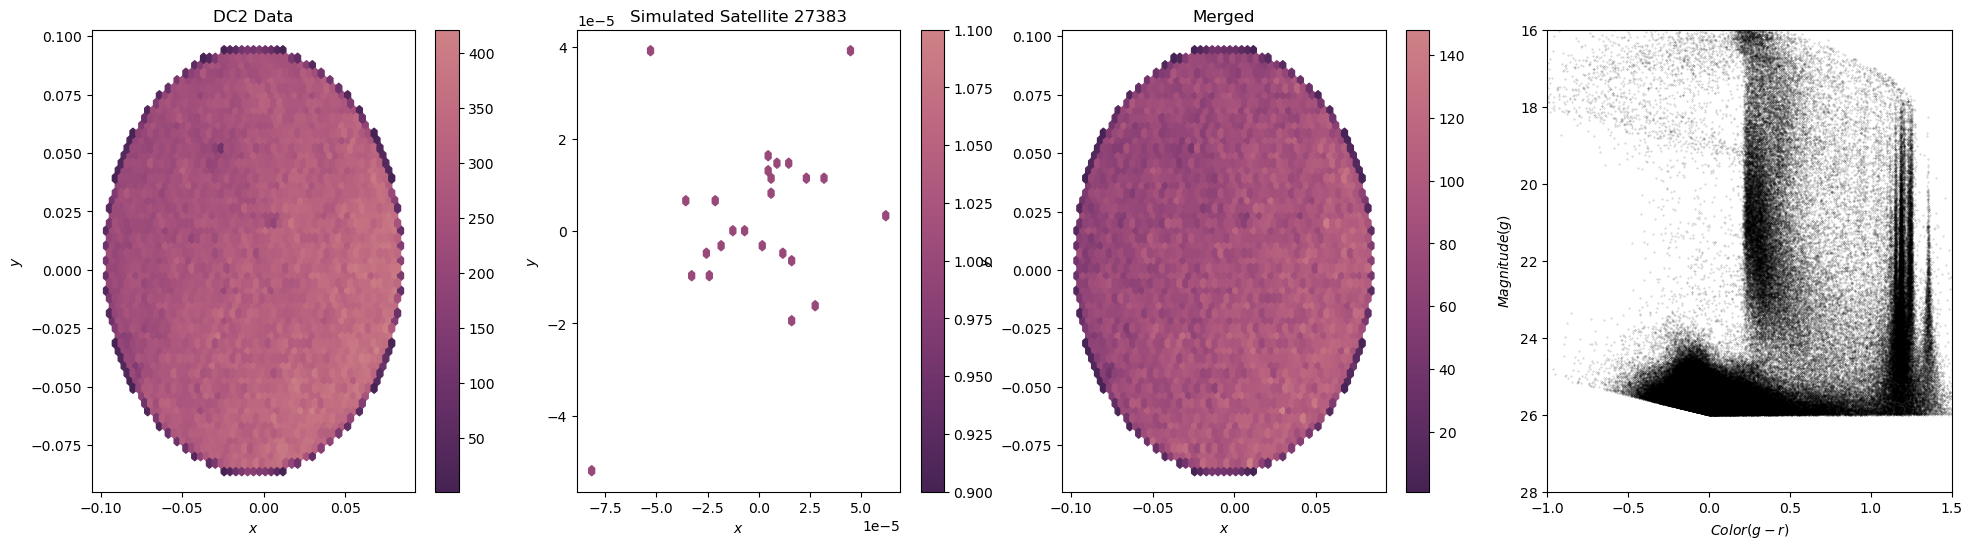

Searching for MC_SOURCE_ID  27383
Characteristic density = 1900.0 deg^-2
Fitting aperture to hotspot...
Characteristic density local = 1991.4 deg^-2 = 0.553 arcmin^-2
Candidate: x_peak:       -0.765, y_peak:        0.245, r_peak:        0.050, sig:        3.755, ra_peak:       54.247, dec_peak:      -38.399
Fitting aperture to hotspot...
Characteristic density local = 1979.5 deg^-2 = 0.550 arcmin^-2
Candidate: x_peak:       -0.695, y_peak:        0.455, r_peak:        0.050, sig:        2.977, ra_peak:       54.339, dec_peak:      -38.189
Fitting aperture to hotspot...
Characteristic density local = 1897.9 deg^-2 = 0.527 arcmin^-2
Candidate: x_peak:       -0.025, y_peak:        1.095, r_peak:        0.030, sig:        3.611, ra_peak:       55.192, dec_peak:      -37.553
Fitting aperture to hotspot...
Characteristic density local = 1744.7 deg^-2 = 0.485 arcmin^-2
Candidate: x_peak:        0.105, y_peak:       -0.545, r_peak:        0.250, sig:        4.575, ra_peak:       55.359, dec_pe

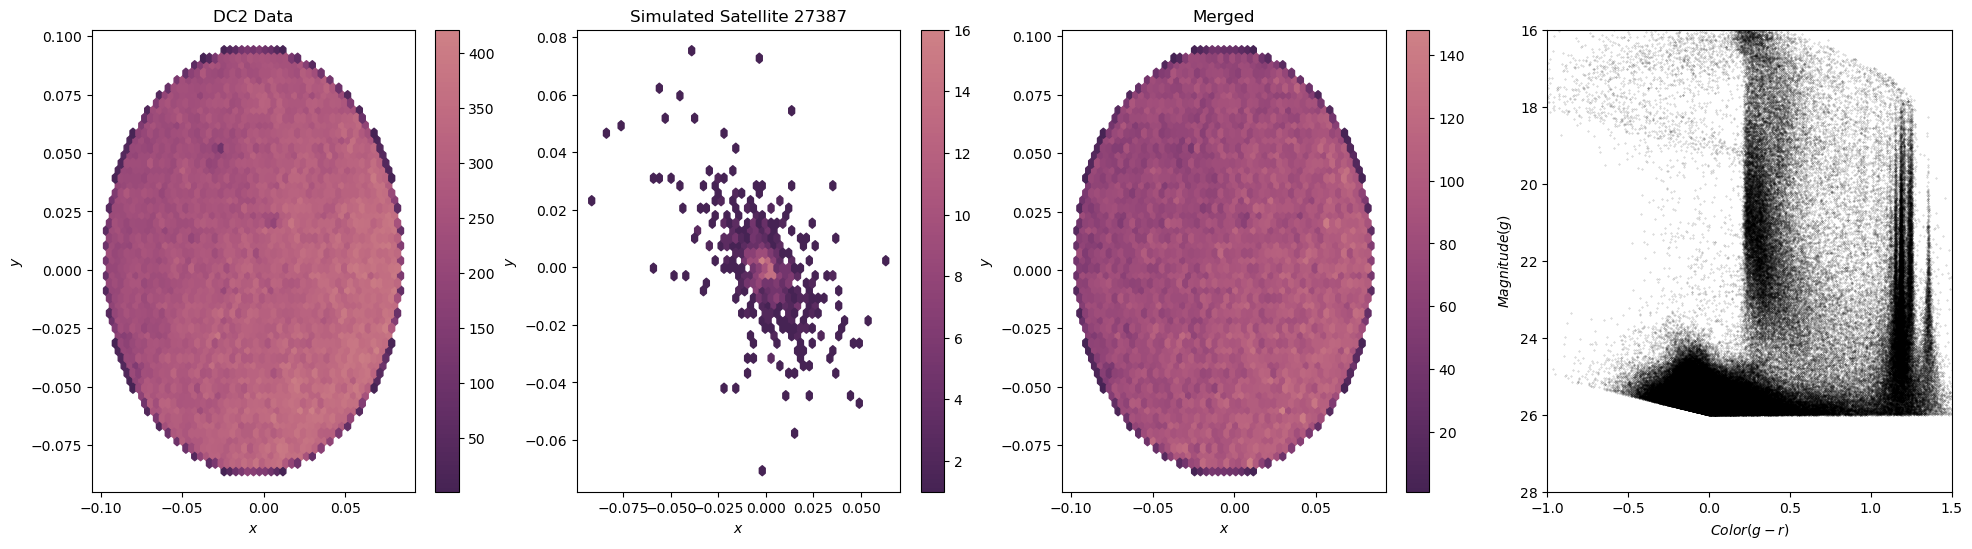

Searching for MC_SOURCE_ID  27387
Characteristic density = 1600.0 deg^-2
Fitting aperture to hotspot...
Characteristic density local = 1539.8 deg^-2 = 0.428 arcmin^-2
Candidate: x_peak:       -1.085, y_peak:       -0.005, r_peak:        0.040, sig:        3.325, ra_peak:       53.834, dec_peak:      -38.645
Fitting aperture to hotspot...
Characteristic density local = 1645.3 deg^-2 = 0.457 arcmin^-2
Candidate: x_peak:       -0.935, y_peak:        0.175, r_peak:        0.030, sig:        4.013, ra_peak:       54.029, dec_peak:      -38.467
Fitting aperture to hotspot...
Characteristic density local = 1484.1 deg^-2 = 0.412 arcmin^-2
Candidate: x_peak:       -0.455, y_peak:       -1.305, r_peak:        0.030, sig:        4.294, ra_peak:       54.630, dec_peak:      -39.951
Fitting aperture to hotspot...
Characteristic density local = 1800.4 deg^-2 = 0.500 arcmin^-2
Candidate: x_peak:        0.035, y_peak:        0.075, r_peak:        0.240, sig:        7.667, ra_peak:       55.268, dec_pe

In [23]:
for i, file in enumerate(population_file):
    name = file
    start = name.find('0')
    end = start + 15
    mcids = name[start:end]
    print(mcids)
    # Set and check for output locations
    # outfile = f'07_sims_v7_final_mag_cut/sim_pop_{mcids}.csv'
    # if os.path.exists(f'results_dir/{outfile}'):
    #     print(f'Files {outfile} already processed')
    #     continue

    with open('config.yaml') as ymlfile:
        cfg = yaml.load(ymlfile, Loader=yaml.SafeLoader)
        survey = simple_adl.survey.Survey(cfg)

    sim_population = fits.read(file)
    sim_positions = np.unique(sim_population[['RA', 'DEC']])
    sim_population  = sim_population.byteswap().newbyteorder()    # resetting byte order for compatibility
    # Filter out sims on edge of DC2 footprint
    sim_population = sim_population[sim_population['FRACDET_CORE'] == 1]
    sim_population = sim_population[sim_population['FRACDET_WIDE'] == 1]
    sim_population = sim_population[sim_population['FRACDET_HALF'] == 1]
    radius = 2 # degrees
    # Find sims at given positions
    for iii,position in enumerate(sim_positions):
        sim_population_at_position = sim_population[sim_population[['RA', 'DEC']] == position]
        t = pd.DataFrame(sim_population_at_position)
        if len(t['MC_SOURCE_ID'].values) == 0:
            print(f'No sims at {position}')
            continue
            
        print(f'Querying region {position}')
        real_data = query(service, position[0], position[1], radius)
        print('Satellites at ', position, ':\n', t['MC_SOURCE_ID'].values)
        for mcid in sim_population_at_position['MC_SOURCE_ID']:
            sim_data = load_sim_data(sim_dir, mcid)
            if sim_data is not None:
                sim_data = sim_data.byteswap().newbyteorder()   # resetting byte order for compatibility
                sim_data = pd.DataFrame(sim_data)
                # mask to only use sims within the queried data's footprint
                c2 = SkyCoord(sim_data['ra'], sim_data['dec'], unit='deg', frame='icrs')
                center = SkyCoord(position[0], position[1], unit='deg')
                d2d = center.separation(c2) 
                catalogmsk = d2d < radius*u.deg
                sim_data = sim_data[catalogmsk]
                if sim_data.empty:
                    print(f'No sim data to inject into region at ({position[0]},{position[1]}) after applying mask')
                    continue

                # merging the sims and dc2 data
                frames = [real_data[real_data.columns[:-1]], sim_data[real_data.columns[:-1]]]
                merged_data = pd.concat(frames)  # pd.Dataframe
                # perform mag cut on the merged data
                good_snr = (merged_data['magerr_g'] < 0.2) & (merged_data['magerr_r'] < 0.2)
                merged_data = merged_data[good_snr]
                good_mag = (merged_data['mag_g'] < survey.catalog['mag_max']) & (merged_data['mag_r'] < survey.catalog['mag_max'])
                merged_data = merged_data[good_mag]
                
                plots(position, real_data, sim_data, merged_data, mcid, cmap)
                print('Searching for MC_SOURCE_ID ', mcid)
                ra = position[0]
                dec = position[1]
                region = simple_adl.survey.Region(survey, ra, dec)
                region.data = merged_data

                # Scan in distance moduli    
                distance_modulus = t.loc[t['MC_SOURCE_ID'] == mcid]['DISTANCE_MODULUS']
                distance_modulus = distance_modulus.values[0]
                # Create isochrone
                iso_search = simple_adl.isochrone.Isochrone(survey=survey.isochrone['survey'],
                                                       band_1=survey.band_1.lower(),
                                                       band_2=survey.band_2.lower(),
                                                       age=12.0, #survey.isochrone['age'],
                                                       metallicity=0.00010, #survey.isochrone['metallicity'],
                                                       distance_modulus=distance_modulus)

                iso_selection = cut_isochrone_path(region.data[survey.mag_dered_1], 
                                                      region.data[survey.mag_dered_2],
                                                      region.data[survey.mag_err_1],
                                                      region.data[survey.mag_err_2],
                                                      iso_search,
                                                      survey.catalog['mag_max'],
                                                      radius=0.1)
                
                results = search_by_distance(survey, region, distance_modulus, iso_selection) 
                ra_peak_array, dec_peak_array, r_peak_array, sig_peak_array, distance_modulus_array, n_obs_peak_array, n_obs_half_peak_array, n_model_peak_array = np.asarray(results)
                best_ra_peak, best_dec_peak, best_r_peak, best_distance_modulus, n_obs_peak, n_obs_half_peak, n_model_peak, best_sig_peak = 0, 0, 0, 0, 0, 0, 0, 0

                if mcid: 
                    mc_source_id_array = np.full_like(distance_modulus_array, mcid)
                else:
                    mc_source_id_array = np.zeros(len(distance_modulus_array))

                # Sort peaks according to significance
                index_sort = np.argsort(sig_peak_array)[::-1]
                ra_peak_array = ra_peak_array[index_sort]
                dec_peak_array = dec_peak_array[index_sort]
                r_peak_array = r_peak_array[index_sort]
                sig_peak_array = sig_peak_array[index_sort]
                distance_modulus_array = distance_modulus_array[index_sort]
                n_obs_peak_array = n_obs_peak_array[index_sort]
                n_obs_half_peak_array = n_obs_half_peak_array[index_sort]
                n_model_peak_array = n_model_peak_array[index_sort]
                mc_source_id_array = mc_source_id_array[index_sort]

                # Collect overlapping peaks
                for ii in range(0, len(sig_peak_array)):
                    if sig_peak_array[ii] < 0:
                        continue
                    sep = angsep(ra_peak_array[ii], dec_peak_array[ii], ra_peak_array, dec_peak_array)
                    sig_peak_array[(sep < r_peak_array[ii]) & (np.arange(len(sig_peak_array)) > ii)] = -1.

                # Prune the list of peaks
                ra_peak_array = ra_peak_array[sig_peak_array > 0.]
                dec_peak_array = dec_peak_array[sig_peak_array > 0.]
                r_peak_array = r_peak_array[sig_peak_array > 0.]
                distance_modulus_array = distance_modulus_array[sig_peak_array > 0.]
                n_obs_peak_array = n_obs_peak_array[sig_peak_array > 0.]
                n_obs_half_peak_array = n_obs_half_peak_array[sig_peak_array > 0.]
                n_model_peak_array = n_model_peak_array[sig_peak_array > 0.]
                mc_source_id_array = mc_source_id_array[sig_peak_array > 0.]
                sig_peak_array = sig_peak_array[sig_peak_array > 0.] # Update the sig_peak_array last!

                if sig_peak_array[0] > best_sig_peak:
                    best_sig_peak = sig_peak_array[0]
                    best_ra_peak = ra_peak_array[0]
                    best_dec_peak = dec_peak_array[0]
                    best_r_peak = r_peak_array[0]
                    best_distance_modulus = distance_modulus_array[0]
                    n_obs_peak = n_obs_peak_array[0]
                    n_obs_half_peak = n_obs_half_peak_array[0]
                    n_model_peak = n_model_peak_array[0]
                    mc_source_id = mc_source_id_array[0]

                del merged_data
                
                for ii in range(0, len(sig_peak_array)):
                    print('{:0.2f} sigma; (RA, Dec) = ({:0.2f}, {:0.2f}); r = {:0.2f} deg; d = {:0.1f}, mu = {:0.2f} mag, mc_source_id: {:0.2f}'.format(sig_peak_array[ii], 
                             ra_peak_array[ii], 
                             dec_peak_array[ii], 
                             r_peak_array[ii],
                             distanceModulusToDistance(distance_modulus_array[ii]),
                             distance_modulus_array[ii],
                             mc_source_id_array[ii]))  

                if best_sig_peak < 5.5:
                    print(f'--> {mcid} NOT FOUND')
                    print('---------------------------------')
                    # try:
                    #     if (len(sig_peak_array) > 0):
                    #         write_output(survey.output['results_dir'], survey.catalog['nside'], region.pix_center, best_ra_peak, best_dec_peak,
                    #                         best_r_peak, best_distance_modulus, 
                    #                         n_obs_peak, n_obs_half_peak, n_model_peak, 
                    #                         best_sig_peak, mcid, 0, outfile)
                    #     else:
                    #         print('No significant hotspots found.')
                    #         nan_array = [np.nan]
                    #         write_output(survey.output['results_dir'], survey.catalog['nside'], region.pix_center,
                    #                          nan_array, nan_array, nan_array, nan_array, 
                    #                          nan_array, nan_array, nan_array, nan_array,
                    #                          [mc_source_id], 0, outfile)
                    # except Exception as e: 
                    #     print(e)
                    #     print('Data missing, cannot write to file')

                else:   
                    print(f'--> {mcid} FOUND')
                    print('---------------------------------')
                    # try:
                    #     if (len(sig_peak_array) > 0):
                    #         write_output(survey.output['results_dir'], survey.catalog['nside'], region.pix_center, best_ra_peak, best_dec_peak,
                    #                         best_r_peak, best_distance_modulus, 
                    #                         n_obs_peak, n_obs_half_peak, n_model_peak, 
                    #                         best_sig_peak, mcid, 0, outfile)
                    #     else:
                    #         print('No significant hotspots found.')
                    #         nan_array = [np.nan]
                    #         write_output(survey.output['results_dir'], survey.catalog['nside'], region.pix_center,
                    #                          nan_array, nan_array, nan_array, nan_array, 
                    #                          nan_array, nan_array, nan_array, nan_array,
                    #                          [mc_source_id], 0, outfile)
                    # except Exception as e: 
                    #     print(e)
                    #     print('Data missing, cannot write to file')
        break
    break

## Results plots

In [5]:
#setting up sim dataframes

catalog_dir = '/project/shared/data/satsim/lsst_dc2_v7' 
results_dir = 'results_dir/v7_sims'
simsv7 = load_simdf(catalog_dir, results_dir)

catalog_dir = '/project/shared/data/satsim/lsst_dc2_v6' 
results_dir = 'results_dir/v6_sims'
simsv6 = load_simdf(catalog_dir, results_dir)

/home/kb/software/simple_adl/simple_adl/plot_osf.py:198: RuntimeWarning: invalid value encountered in divide
  pdet = ndet.astype(float)/total


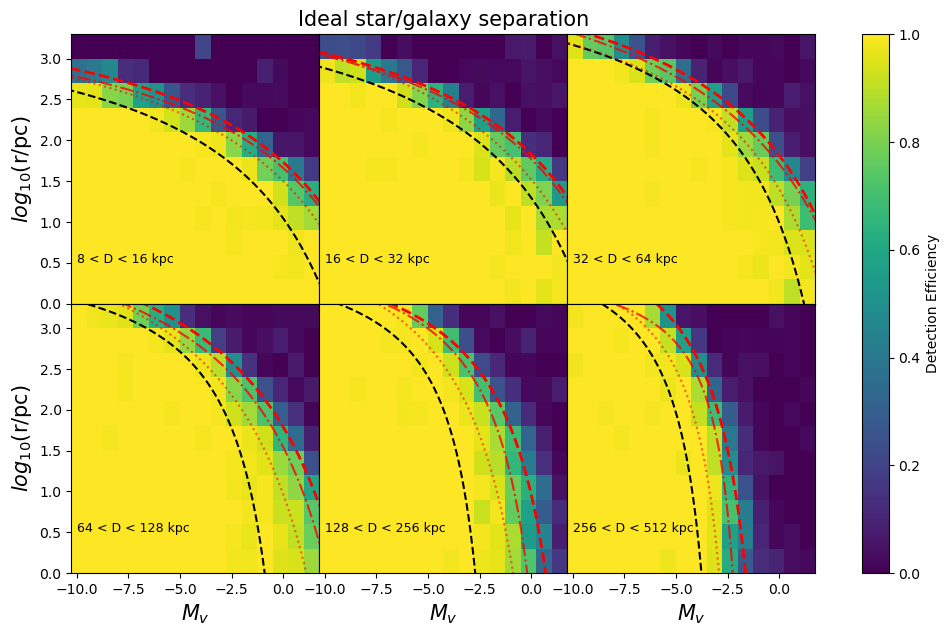

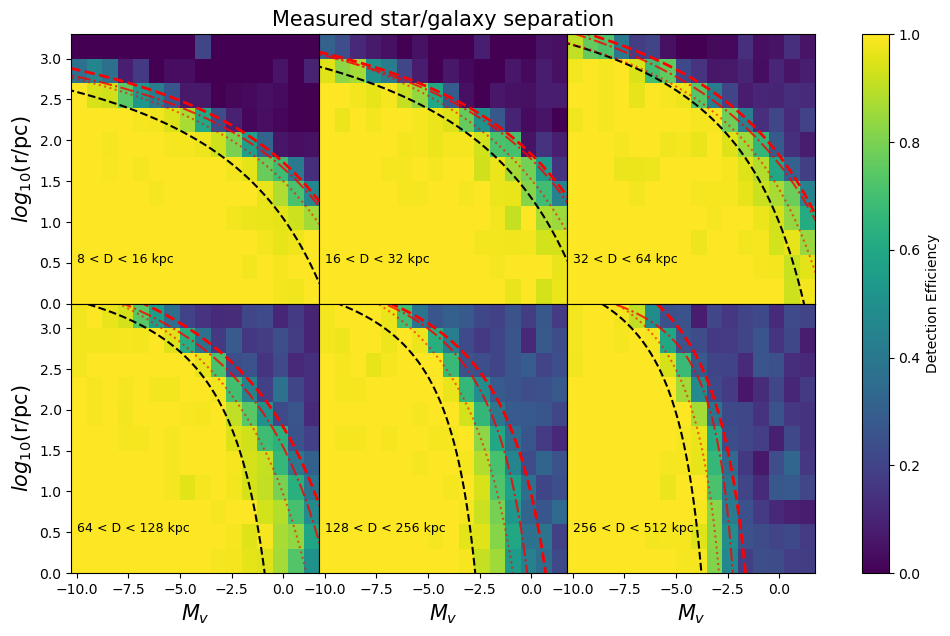

In [6]:
# plot observational selection functions
plot_osf(simsv7, "Ideal star/galaxy separation", save=False, out_name='quick_osfv7.jpg')
plot_osf(simsv6, "Measured star/galaxy separation", save=False, out_name='quick_osfv6.jpg')
#plot_osf(simsv6, "Measured star/galaxy separation (corrected)", save=False, out_name='measured_corr_osf.pdf', threshold=8.4)

### Analytic approximation for 50% detection efficiency contour

In [26]:
def func(x,a,b,c):
    return a/(x - b) + c

In [27]:
# Initial guess
P0=[[11.3 ,  10.0 ,  4.0  ],
    [22.6 ,  10.0 ,  4.3  ],
    [45.2 ,  6.0  ,  4.3  ],
    [90.5 ,  4.7  ,  4.3  ],
    [181.0,  2.1  ,  4.3  ],
    [362.0,  -0.7 ,  4.6  ],]

BOUNDS = [[0, -10, 3.5], #lower bounds for each column
          [512, 10, 5.0]] #upper bounds for each column

files = sorted(glob.glob('lsst_corrected_p50_d*.npy'))
results = []

for i,f in enumerate(files):
    dist = float(f.rsplit('_')[-1].rsplit('.',1)[0].strip('d'))
    data = np.load(f)
    sigma = 0.05*np.ones(len(data[:,1]))
    sigma[0] = 0.5
    sigma[-1] = 0.5
    #print sigma
    r = curve_fit(func,data[:,0],data[:,1],p0=P0[i],sigma=sigma,bounds=BOUNDS)
    results += [[dist]+r[0].tolist()]

results = np.asarray(results)
results = results[np.argsort(results[:,0])]

print('%-5s  %-5s  %-5s  %-5s'%('Dist','A0','Mv0','logr0'))
for r in results:
    print('[%-5.1f,  %-5.1f,  %-5.1f,  %-5.1f],'%tuple(r))

Dist   A0     Mv0    logr0
[11.3 ,  25.0 ,  10.0 ,  4.0  ],
[22.6 ,  30.8 ,  10.0 ,  4.6  ],
[45.2 ,  20.7 ,  6.9  ,  4.4  ],
[90.5 ,  23.4 ,  5.8  ,  5.0  ],
[181.0,  14.3 ,  2.1  ,  4.8  ],
[362.0,  6.5  ,  -1.4 ,  4.3  ],


# XGBoost Classifier

In [5]:
ssf_v6 = selection_function.SurveySelectionFunction('config.yaml', lsst_version=6)
ssf_v7 = selection_function.SurveySelectionFunction('config.yaml', lsst_version=7)

Loading /home/kb/lsst_wfd_toy.fits...
Loading /home/kb/lsst_wfd_toy.fits...


In [6]:
ssf_v6.train_classifier()

Ntrain =  54116; Ntest = 6013 
Training XGBClassifier...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/home/kb/software/dc2_satellite_census/code/utils.py:383: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SIG'][data['DIFFICULTY'] == 1] = np.nan
/home/kb/software/dc2_satellite_census/code/utils.py:384: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SIG'][data['DIFFICULTY'] == 2] = 99
/home/kb/.conda/envs/simple/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/kb/.conda/envs/simple/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_spa

{'learning_rate': 0.05, 'max_delta_step': 1, 'max_depth': 7, 'n_estimators': 100, 'seed': 1337}
  ... training took 453.97 seconds


In [7]:
ssf_v7.train_classifier()

Ntrain =  54068; Ntest = 6008 
Training XGBClassifier...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/home/kb/software/dc2_satellite_census/code/utils.py:383: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SIG'][data['DIFFICULTY'] == 1] = np.nan
/home/kb/software/dc2_satellite_census/code/utils.py:384: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SIG'][data['DIFFICULTY'] == 2] = 99
/home/kb/.conda/envs/simple/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/kb/.conda/envs/simple/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_spa

{'learning_rate': 0.1, 'max_delta_step': 1, 'max_depth': 6, 'n_estimators': 100, 'seed': 1337}
  ... training took 443.71 seconds


In [8]:
ssf_v6.write_classifier('classifiers/v6_classifier2.0.model', force=True)
ssf_v7.write_classifier('classifiers/v7_classifier2.0.model', force=True)

Saving model...
Saving model...


In [34]:
# example of classifier prediction

ssf.load_classifier('v6_classifier.model')                       # load classifier
size = 1                                                         # number of satellites
distance = np.random.uniform(8, 16, size)                        # kpc
abs_mag = np.random.uniform(-10, 2.5, size)                      # mag
r_physical = np.logspace(-3.5, 0, size)                          # kpc
x_eval = np.vstack([abs_mag, np.log10(r_physical), distance]).T
pdet = ssf.classifier.predict_proba(x_eval)[:,1]
print(pdet)                                                      # probability of detection

Loading classifier from v6_classifier.model ...
[0.98399043]


In [35]:
pdet = ssf.classifier.predict_proba(ssf.X_train)[:,1]

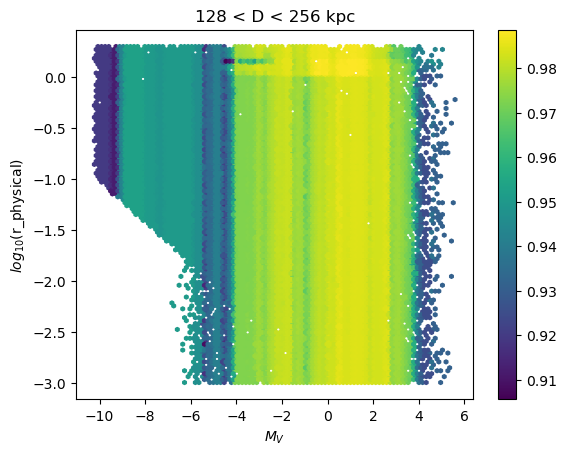

In [36]:
plt.hexbin(ssf.X_train[:,0], ssf.X_train[:,1], C=pdet, cmap='viridis')
plt.xlabel(r'$M_V$')
plt.ylabel(r'$log_{10}$(r_physical)')
plt.title('128 < D < 256 kpc')
plt.colorbar()
plt.show()

In [24]:
ssf.load_classifier('v6_classifier.model')

Loading classifier from v6_classifier.model ...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=1,
              max_depth=7, max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=None, ...)

### Bunch of plots for verification

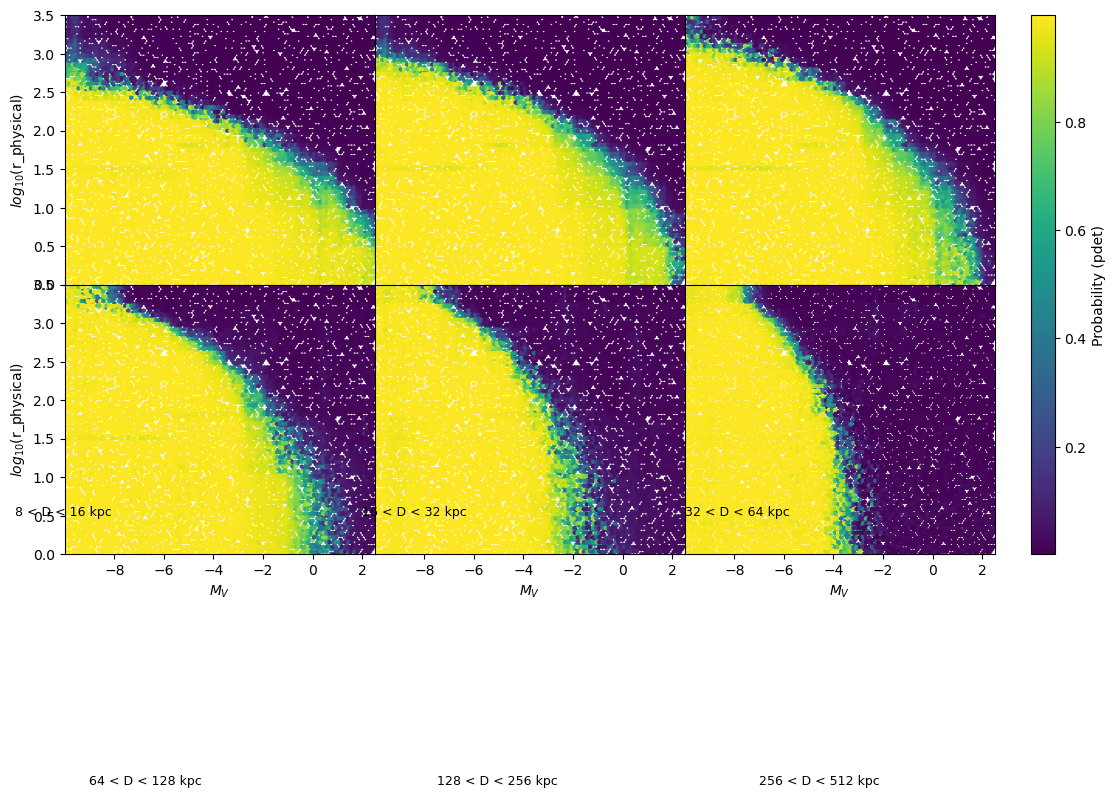

In [67]:
fig,axes = plt.subplots(2,3,figsize=(12,7))
plt.subplots_adjust(wspace=0, hspace=0)
axes[0,0].axes.get_xaxis().set_visible(False)
axes[0,1].axes.get_yaxis().set_visible(False)
axes[0,2].axes.get_yaxis().set_visible(False)
axes[1,2].axes.get_yaxis().set_visible(False)
axes[1,1].axes.get_yaxis().set_visible(False)
size = 20000
distance = np.random.uniform(8, 16, size)
abs_mag = np.random.uniform(-10, 2.5, size)
r_physical = np.logspace(0, 3.5, size)
x_eval = np.vstack([abs_mag, np.log10(r_physical), distance]).T
pdet = ssf.classifier.predict_proba(x_eval)[:,1]
axes[0,0].hexbin(abs_mag, np.log10(r_physical), C=pdet, cmap='viridis')
axes[0,0].set_xlabel(r'$M_V$')
axes[0,0].set_ylabel(r'$log_{10}$(r_physical)')
axes[0, 0].set_xlim(abs_mag.min(), abs_mag.max())
axes[0, 0].set_ylim(np.log10(r_physical.min()), np.log10(r_physical.max()))
plt.text(-37, 0.5, "8 < D < 16 kpc", fontsize=9)

distance = np.random.uniform(16, 32, size)
x_eval = np.vstack([abs_mag, np.log10(r_physical), distance]).T
pdet = ssf.classifier.predict_proba(x_eval)[:,1]
axes[0,1].hexbin(abs_mag, np.log10(r_physical), C=pdet, cmap='viridis')
axes[0,1].set_xlabel(r'$M_V$')
axes[0,1].set_ylabel(r'$log_{10}$(r_physical)')
axes[0, 1].set_xlim(abs_mag.min(), abs_mag.max())
axes[0, 1].set_ylim(np.log10(r_physical.min()), np.log10(r_physical.max()))
plt.text(-23, 0.5, "16 < D < 32 kpc", fontsize=9)

distance = np.random.uniform(32, 64, size)
x_eval = np.vstack([abs_mag, np.log10(r_physical), distance]).T
pdet = ssf.classifier.predict_proba(x_eval)[:,1]
axes[0,2].hexbin(abs_mag, np.log10(r_physical), C=pdet, cmap='viridis')
axes[0,2].set_xlabel(r'$M_V$')
axes[0,2].set_ylabel(r'$log_{10}$(r_physical)')
axes[0, 2].set_xlim(abs_mag.min(), abs_mag.max())
axes[0, 2].set_ylim(np.log10(r_physical.min()), np.log10(r_physical.max()))

plt.text(-10, 0.5, "32 < D < 64 kpc", fontsize=9)

distance = np.random.uniform(64, 128, size)
x_eval = np.vstack([abs_mag, np.log10(r_physical), distance]).T
pdet = ssf.classifier.predict_proba(x_eval)[:,1]
axes[1,0].hexbin(abs_mag, np.log10(r_physical), C=pdet, cmap='viridis')
axes[1,0].set_xlabel(r'$M_V$')
axes[1,0].set_ylabel(r'$log_{10}$(r_physical)')
axes[1, 0].set_xlim(abs_mag.min(), abs_mag.max())
axes[1, 0].set_ylim(np.log10(r_physical.min()), np.log10(r_physical.max()))

plt.text(-34, -3, "64 < D < 128 kpc", fontsize=9)

distance = np.random.uniform(128, 256, size)
x_eval = np.vstack([abs_mag, np.log10(r_physical), distance]).T
pdet = ssf.classifier.predict_proba(x_eval)[:,1]
axes[1,1].hexbin(abs_mag, np.log10(r_physical), C=pdet, cmap='viridis')
axes[1,1].set_xlabel(r'$M_V$')
axes[1,1].set_ylabel(r'$log_{10}$(r_physical)')
axes[1, 1].set_xlim(abs_mag.min(), abs_mag.max())
axes[1, 1].set_ylim(np.log10(r_physical.min()), np.log10(r_physical.max()))

plt.text(-20, -3, "128 < D < 256 kpc", fontsize=9)

distance = np.random.uniform(256, 512, size)
x_eval = np.vstack([abs_mag, np.log10(r_physical), distance]).T
pdet = ssf.classifier.predict_proba(x_eval)[:,1]
axes[1,2].hexbin(abs_mag, np.log10(r_physical), C=pdet, cmap='viridis')
axes[1,2].set_xlabel(r'$M_V$')
axes[1,2].set_ylabel(r'$log_{10}$(r_physical)')
axes[1, 2].set_xlim(abs_mag.min(), abs_mag.max())
axes[1, 2].set_ylim(np.log10(r_physical.min()), np.log10(r_physical.max()))

plt.text(-7, -3, "256 < D < 512 kpc", fontsize=9)

cax = fig.add_axes([0.93, 0.11, 0.02, 0.77])
cbar = fig.colorbar(axes[1, 2].hexbin(abs_mag, np.log10(r_physical), C=pdet, cmap='viridis'), cax=cax)
cbar.set_label('Probability (pdet)')

plt.show()

In [7]:
v6_dir = 'results_dir/v6_sims'
v7_dir = 'results_dir/v7_sims'
v6_files = glob.glob(os.path.join(v6_dir, '*.csv'))
v7_files = glob.glob(os.path.join(v7_dir, '*.csv'))




In [9]:
help(pd.concat)

Help on function concat in module pandas.core.reshape.concat:

concat(objs: 'Iterable[Series | DataFrame] | Mapping[HashableT, Series | DataFrame]', *, axis: 'Axis' = 0, join: 'str' = 'outer', ignore_index: 'bool' = False, keys=None, levels=None, names: 'list[HashableT] | None' = None, verify_integrity: 'bool' = False, sort: 'bool' = False, copy: 'bool | None' = None) -> 'DataFrame | Series'
    Concatenate pandas objects along a particular axis.

    Allows optional set logic along the other axes.

    Can also add a layer of hierarchical indexing on the concatenation axis,
    which may be useful if the labels are the same (or overlapping) on
    the passed axis number.

    Parameters
    ----------
    objs : a sequence or mapping of Series or DataFrame objects
        If a mapping is passed, the sorted keys will be used as the `keys`
        argument, unless it is passed, in which case the values will be
        selected (see below). Any None objects will be dropped silently unles